In [1]:
import pandas as pd

df_complaints = pd.read_csv("Complaints.zip", compression="zip", low_memory=False)
df_complaints = df_complaints.dropna(subset=["NEIGHBORHOOD", "CREATED_ON"])

df_complaints["CREATED_ON"] = pd.to_datetime(df_complaints["CREATED_ON"], errors="coerce")
df_complaints = df_complaints.dropna(subset=["CREATED_ON"])  # drop rows that failed to parse
df_complaints["Year"] = df_complaints["CREATED_ON"].dt.year

complaints_by_neighborhood = (
    df_complaints
    .groupby("NEIGHBORHOOD")
    .size()
    .reset_index(name="Complaint_Count")
)

top10_least_complaints = (
    complaints_by_neighborhood
    .sort_values("Complaint_Count", ascending=True)
    .head(10)
)

print("Top 10 neighborhoods with the least total complaints:")
print(top10_least_complaints)

top10_neighborhoods = top10_least_complaints["NEIGHBORHOOD"].tolist()
df_top10 = df_complaints[df_complaints["NEIGHBORHOOD"].isin(top10_neighborhoods)]

complaints_per_year = (
    df_top10
    .groupby(["NEIGHBORHOOD", "Year"])
    .size()
    .reset_index(name="Complaint_Count")
)

print("\nYearly complaint counts (sorted from lowest to highest) for each of the top 10 neighborhoods:")
for nhood in top10_neighborhoods:
    sub = (
        complaints_per_year[complaints_per_year["NEIGHBORHOOD"] == nhood]
        .sort_values("Complaint_Count", ascending=True)
    )
    print(f"\nNeighborhood: {nhood}")
    print(sub[["Year", "Complaint_Count"]].to_string(index=False))

Top 10 neighborhoods with the least total complaints:
            NEIGHBORHOOD  Complaint_Count
52  Mount Oliver Borough               64
4      Arlington Heights              140
35            Glen Hazel              443
58     Northview Heights              661
26         East Carnegie              666
67             Ridgemont              714
20        Chartiers City              823
78             St. Clair              888
31             Fairywood             1048
37                  Hays             1157

Yearly complaint counts (sorted from lowest to highest) for each of the top 10 neighborhoods:

Neighborhood: Mount Oliver Borough
 Year  Complaint_Count
 2021                2
 2018                5
 2020                5
 2022                5
 2015                6
 2017                6
 2019                9
 2016               26

Neighborhood: Arlington Heights
 Year  Complaint_Count
 2020                6
 2015               12
 2016               14
 2018               1

In this cell, I focus on identifying which neighborhoods generate the fewest service complaints overall. I start by cleaning the complaint records to remove entries with missing neighborhoods or date information, then I extract the year from each timestamp so I can look at how complaints fluctuate over time. Grouping by neighborhood lets me see which areas report the least issues, and then I break those places down further by year to verify that low complaint totals are consistent rather than accidental. This step is similar to examining how often a computer system malfunctions before diagnosing what is actually wrong. I cannot judge quality based only on what a system looks like; I need to see how frequently people report problems and whether those problems persist across time.

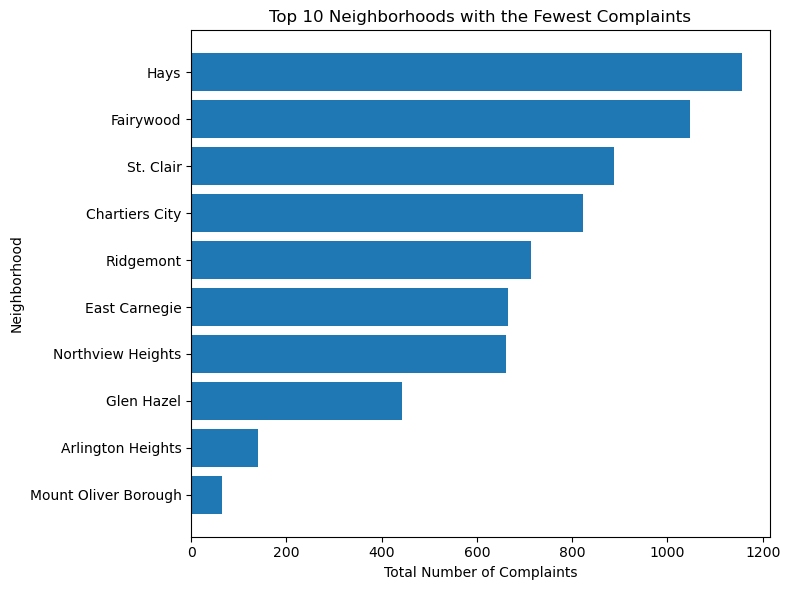

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Load the complaints dataset
df_complaints = pd.read_csv("Complaints.zip", compression="zip", low_memory=False)
# 2. Drop rows with missing neighborhood
df_complaints = df_complaints.dropna(subset=["NEIGHBORHOOD"])

complaints_by_neighborhood = (
    df_complaints
    .groupby("NEIGHBORHOOD")
    .size()
    .reset_index(name="Complaint_Count")
)

top10_least = (
    complaints_by_neighborhood
    .sort_values("Complaint_Count", ascending=True)
    .head(10)
)

plt.figure(figsize=(8, 6))
plt.barh(
    top10_least["NEIGHBORHOOD"],
    top10_least["Complaint_Count"]
)
plt.xlabel("Total Number of Complaints")
plt.ylabel("Neighborhood")
plt.title("Top 10 Neighborhoods with the Fewest Complaints")
plt.tight_layout()
plt.show()

Here, I visualize the neighborhoods with the fewest complaints using a horizontal bar chart. Displaying the results this way makes the information easier to compare at a glance, so I can immediately recognize which areas receive the least service issues. The horizontal layout works especially well when neighborhood names are long or numerous, helping me avoid clutter that would hide the pattern. Even though this step still relies on raw totals, it sets a baseline for how different neighborhoods behave: some places simply do not report many problems. Just like in system monitoring, certain machines rarely show warnings, but I still cannot assume they are better until I account for how much they are used and who interacts with them.

In [2]:
import pandas as pd

# load complaints and population data
df_complaints = pd.read_csv("Complaints.zip", compression="zip", low_memory=False)
df_complaints = df_complaints.dropna(subset=["NEIGHBORHOOD"])

pop_df = pd.read_csv("preliminarycitypittsburghneighborhood_pl94171summary-2.csv", low_memory=False)

# normalize neighborhood names (strip spaces, fix dashes)
def fix_name(s):
    if pd.isna(s):
        return s
    return s.strip().replace("–", "-").replace("—", "-")

df_complaints["Neighborhood_norm"] = df_complaints["NEIGHBORHOOD"].map(fix_name)
pop_df["Neighborhood_norm"]       = pop_df["Neighborhood"].map(fix_name)

# same combined-neighborhood mapping used in Crime and Trees
combine = {
    "Arlington": "Arlington - Arlington Heights (Combined)",
    "Arlington Heights": "Arlington - Arlington Heights (Combined)",
    "Central Business District": "Central Business District (Downtown)",
    "Chartiers": "Chartiers City",
    "Mount Oliver": "Mt. Oliver",
    "Saint Clair": "St. Clair",
    "Southshore": "South Shore",
    "Spring Hill-City View": "Spring Hill-City"
}

df_complaints["Neighborhood_fixed"] = df_complaints["Neighborhood_norm"].replace(combine)


In this cell, I make sure the complaint data is speaking the same language as the population dataset by standardizing neighborhood names. Different datasets often label the same location slightly differently, so I apply the same cleaning logic I used for Crime and Trees and combine the same paired neighborhoods. This ensures that when I connect complaints to population later, I am matching the counts to the correct areas. Without this step, I would risk comparing one label’s complaints with another label’s population, which would distort the whole analysis. It is similar to dealing with multiple device drivers for one piece of hardware: if the system cannot agree on what the device is called, no program can communicate with it reliably.

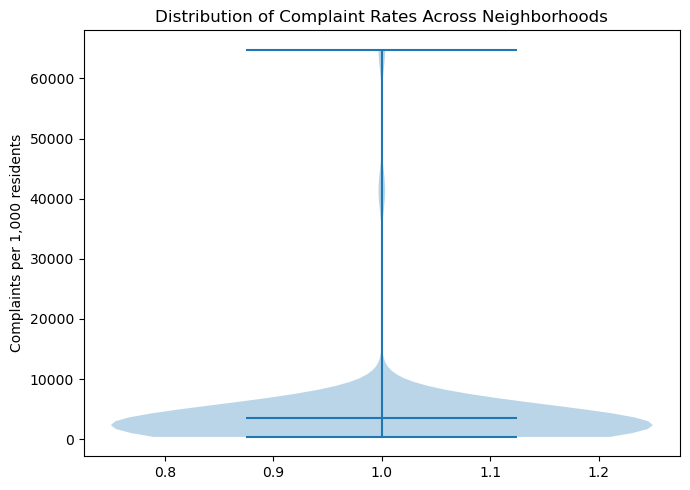

,Neighborhood_fixed,Complaint_Count,2020_Total_Population,Complaints_per_1000
56,Northview Heights,661,1769,373.657434
54,North Oakland,5945,10691,556.075203
9,Bluff,3864,5882,656.919415
34,Glen Hazel,443,659,672.230653
81,Terrace Village,1954,2320,842.241379


In [4]:
import matplotlib.pyplot as plt

# count complaints per neighborhood
complaint_counts = (
    df_complaints
    .dropna(subset=["Neighborhood_fixed"])
    .groupby("Neighborhood_fixed")
    .size()
    .reset_index(name="Complaint_Count")
)

# pull 2020 population and align names
pop_2020 = (
    pop_df[["Neighborhood_norm", "2020_Total_Population"]]
    .dropna()
    .rename(columns={"Neighborhood_norm": "Neighborhood_fixed"})
)

# combine population + complaints
complaints_metrics = complaint_counts.merge(pop_2020, on="Neighborhood_fixed", how="inner")
complaints_metrics = complaints_metrics[complaints_metrics["2020_Total_Population"] > 0]

# complaints per 1000 residents
complaints_metrics["Complaints_per_1000"] = (
    complaints_metrics["Complaint_Count"] / complaints_metrics["2020_Total_Population"] * 1000
)

# sort from lowest to highest complaints per capita (safest first)
complaints_metrics_sorted = complaints_metrics.sort_values("Complaints_per_1000", ascending=True)

# violin plot of distribution of complaints per 1000
plt.figure(figsize=(7, 5))
plt.violinplot(complaints_metrics_sorted["Complaints_per_1000"], vert=True, showmeans=True)
plt.ylabel("Complaints per 1,000 residents")
plt.title("Distribution of Complaint Rates Across Neighborhoods")
plt.tight_layout()
plt.show()

complaints_metrics_sorted.head()


Here, I shift from counting how many complaints come from each neighborhood to measuring how intense those complaints are relative to population size. I join the complaint totals with population data and compute complaints per 1,000 residents. This turns a basic count into something meaningful because a large neighborhood will naturally report more issues, but that does not mean its residents experience more problems individually. The violin plot helps me visualize the spread of complaint intensity across the city, showing not just the average but how uneven the distribution can be. This mirrors how system diagnostics often reveal clusters of issues in specific parts of a device even when the overall system appears stable.

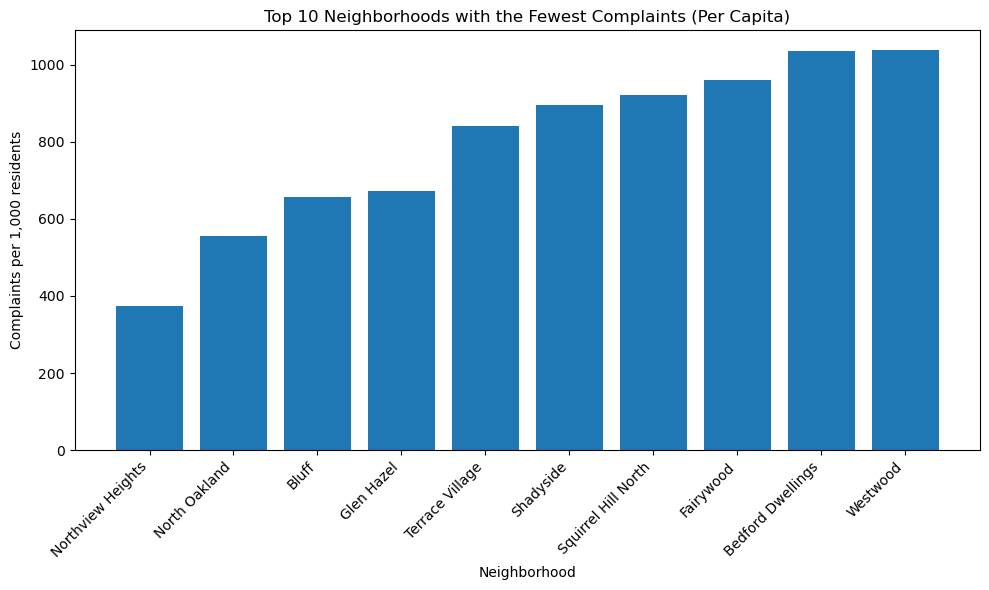

In [5]:
# top 10 neighborhoods with the fewest complaints per 1,000 residents
top10_safest_complaints = complaints_metrics_sorted.head(10)

plt.figure(figsize=(10, 6))
plt.bar(
    top10_safest_complaints["Neighborhood_fixed"],
    top10_safest_complaints["Complaints_per_1000"]
)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Complaints per 1,000 residents")
plt.xlabel("Neighborhood")
plt.title("Top 10 Neighborhoods with the Fewest Complaints (Per Capita)")
plt.tight_layout()
plt.show()


In this cell, I look at the ten neighborhoods with the fewest complaints per 1,000 residents. Unlike the earlier ranking based only on raw totals, this ranking rewards neighborhoods where residents experience fewer issues, not just fewer submissions overall. By displaying these values in a bar chart, I can see which areas consistently deliver the least disruption relative to their population size. This helps separate places that merely submit fewer complaints from places that genuinely run more smoothly. Just like distinguishing between a quiet computer and an efficient computer, I want to know whether low activity reflects strong performance rather than underreporting.

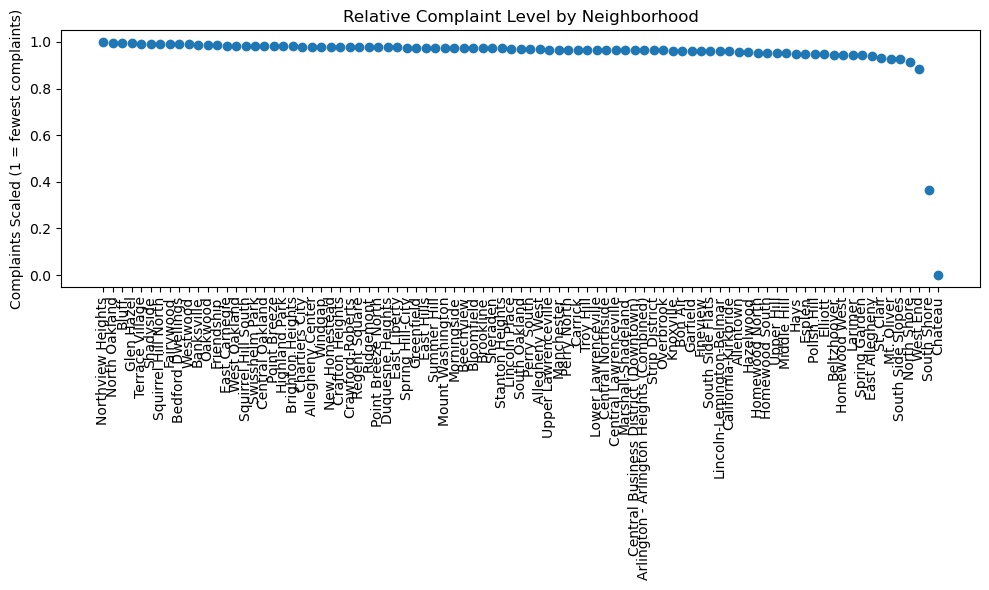

In [6]:
# scale so that 1 = best (fewest complaints), 0 = worst (most complaints)
c_min = complaints_metrics["Complaints_per_1000"].min()
c_max = complaints_metrics["Complaints_per_1000"].max()

if c_max == c_min:
    complaints_metrics["Complaints_Scaled"] = 1.0
else:
    scaled_raw = (complaints_metrics["Complaints_per_1000"] - c_min) / (c_max - c_min)
    complaints_metrics["Complaints_Scaled"] = 1 - scaled_raw  # fewer complaints => higher score

# sort again for plotting and inspection
complaints_metrics_sorted2 = complaints_metrics.sort_values("Complaints_per_1000", ascending=True)

plt.figure(figsize=(10, 6))
plt.scatter(
    complaints_metrics_sorted2["Neighborhood_fixed"],
    complaints_metrics_sorted2["Complaints_Scaled"]
)
plt.xticks(rotation=90)
plt.ylabel("Complaints Scaled (1 = fewest complaints)")
plt.title("Relative Complaint Level by Neighborhood")
plt.tight_layout()
plt.show()


Here, I turn complaint intensity into a scaled value between zero and one so that it can be combined with crime and tree metrics later. Because more complaints signal worse neighborhood experience, I invert the scale so that neighborhoods with fewer complaints receive higher scores. The scatter plot shows how every neighborhood fits into this scaled system without emphasizing one group over another through color or style. This transformation mirrors how a troubleshooting score might convert many different machine readings into a single health value. By compressing complaint rates into a uniform metric, I make it possible to integrate them into a broader, balanced view of quality of life.

In [7]:
# ordered from best (fewest complaints) to worst
complaints_final_sorted = complaints_metrics.sort_values("Complaints_Scaled", ascending=False)

complaints_final_sorted.head(15)


,Neighborhood_fixed,Complaint_Count,2020_Total_Population,Complaints_per_1000,Complaints_Scaled
56,Northview Heights,661,1769,373.657434,1.000000
54,North Oakland,5945,10691,556.075203,0.997168
9,Bluff,3864,5882,656.919415,0.995603
34,Glen Hazel,443,659,672.230653,0.995365
81,Terrace Village,1954,2320,842.241379,0.992726
66,Shadyside,13736,15317,896.781354,0.991879
74,Squirrel Hill North,10956,11879,922.299857,0.991483
30,Fairywood,1048,1092,959.706960,0.990902
5,Bedford Dwellings,1435,1386,1035.353535,0.989728
87,Westwood,3457,3332,1037.515006,0.989694


The final cell orders the neighborhoods by their scaled complaint scores, allowing me to see which areas perform best in terms of reducing resident disruptions. At this point, the complaints data has been cleaned, adjusted for population, and translated into a score that reflects lived experience rather than raw counts. In this form, complaints no longer function as individual records; they have become a comparable measurement that can be weighed alongside crime severity and tree accessibility. This table provides the last piece needed to evaluate neighborhoods not simply by what happens there, but by how much those events affect the everyday life of the people who live in them.

## Conclusion ##
The complaints metric shows how frequently residents experience disruptions in the basic services and conditions of their neighborhoods. Working only with raw totals would have rewarded places that simply report less, so shifting to complaints per 1,000 residents exposes which areas actually deliver smoother day-to-day living. By cleaning names, aligning datasets, and scaling the results so fewer complaints increase a neighborhood’s score, I translate service disruptions into a format that fits alongside crime and trees. Complaints_Scaled reflects how well a neighborhood functions from the perspective of the people using it, just like assessing a computer by how reliably it performs rather than by how many parts it contains. With this score complete, complaints now serve as the social stability component of the Quality of Life model, representing the difference between a neighborhood that merely appears calm and one that genuinely causes less frustration for its residents.
